In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

To ensure robust forecasting for our bakery's demand, we implemented two distinct time-series methodologies: SARIMAX and Holt-Winters (Triple Exponential Smoothing). The choice of SARIMAX is justified by its ability to handle both non-stationary data and complex seasonal patterns, while also allowing for potential external variables (exogenous factors) that might influence sales. In parallel, we utilized Holt-Winters as it is specifically designed to decompose data into level, trend, and seasonality—making it highly effective for the strong 7-day weekly cycles identified during our Exploratory Data Analysis (EDA). By comparing these two models, we can balance statistical complexity with computational efficiency, ultimately selecting the most accurate model for each specific product based on their respective Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) scores.

In [2]:
qty_path = "data_tmp/qty_ts.csv"

qty_ts = pd.read_csv(qty_path, index_col=0, parse_dates=True)

print("qty_ts shape:", qty_ts.shape)

qty_ts.head()

qty_ts shape: (600, 12)


,BAGUETTE,BANETTE,BOULE 400G,CAMPAGNE,CEREAL BAGUETTE,COOKIE,CROISSANT,ECLAIR,PAIN AU CHOCOLAT,SPECIAL BREAD,TARTELETTE,TRADITIONAL BAGUETTE
date,,,,,,,,,,,,
2021-01-02,46.0,40.0,11.0,10.0,19.0,8.0,66.0,0.0,48.0,8.0,0.0,128.0
2021-01-03,35.0,35.0,11.0,9.0,16.0,2.0,59.0,0.0,45.0,7.0,0.0,171.0
2021-01-04,30.0,24.0,5.0,6.0,7.0,2.0,17.0,0.0,17.0,7.0,0.0,128.0
2021-01-05,29.0,26.0,6.0,3.0,7.0,6.0,12.0,0.0,6.0,7.0,0.0,99.0
2021-01-07,28.0,21.0,3.0,3.0,7.0,3.0,15.0,0.0,15.0,6.0,0.0,109.0


In [24]:
dict_produits = {}

for produit in qty_ts.columns:
    temp_df = qty_ts[[produit]].copy()
    
    temp_df = temp_df.asfreq('D').fillna(0)
    
    dict_produits[produit] = temp_df

In [42]:
results_list = []

for produit, df_prod in dict_produits.items():
    # 1. Préparation des données (Fréquence + Train/Test)
    df_prod = df_prod.asfreq('D').fillna(0)
    train_size = int(len(df_prod) * 0.8)
    train = df_prod.iloc[:train_size]
    test = df_prod.iloc[train_size:]
    
    # --- MODÈLE 1 : SARIMA ---
    try:
        model_sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7),
                               enforce_stationarity=False, enforce_invertibility=False)
        res_sarima = model_sarima.fit(disp=False)
        forecast_sarima = res_sarima.forecast(steps=len(test))
        mae_sarima = mean_absolute_error(test, forecast_sarima)
        mse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
    except:
        mae_sarima = np.nan

    # --- MODÈLE 2 : HOLT-WINTERS ---
    try:
        model_hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7)
        res_hw = model_hw.fit()
        forecast_hw = res_hw.forecast(len(test))
        mae_hw = mean_absolute_error(test, forecast_hw)
        mse_hw = np.sqrt(mean_squared_error(test, forecast_hw))
    except:
        mae_hw = np.nan

    
    results_list.append({
        "Produit": produit,
        "MAE_SARIMA": mae_sarima,
        "MAE_HoltWinters": mae_hw,
        "RMSE_SARIMA": mse_sarima,
        "RMSE_HoltWinters": mse_hw,
        "Winning_MAE": "SARIMA" if mae_sarima < mae_hw else "Holt-Winters",
        "Winning_RMSE": "SARIMA" if mse_sarima < mse_hw else "Holt-Winters"
    })
    print(f"{produit} analysé.")


df_comp = pd.DataFrame(results_list)
display(df_comp)


print(f"\nThe model most often winning is : {df_comp['Winning_MAE'].mode()[0]} according to MAE and {df_comp['Winning_RMSE'].mode()[0]} according to RMSE.")

BAGUETTE analysé.
BANETTE analysé.
BOULE 400G analysé.
CAMPAGNE analysé.
CEREAL BAGUETTE analysé.
COOKIE analysé.
CROISSANT analysé.
ECLAIR analysé.
PAIN AU CHOCOLAT analysé.
SPECIAL BREAD analysé.
TARTELETTE analysé.
TRADITIONAL BAGUETTE analysé.


,Produit,MAE_SARIMA,MAE_HoltWinters,RMSE_SARIMA,RMSE_HoltWinters,Winning_MAE,Winning_RMSE
0,BAGUETTE,14.527034,14.454086,18.140357,18.817752,Holt-Winters,SARIMA
1,BANETTE,18.342126,18.057441,23.101939,23.945808,Holt-Winters,SARIMA
2,BOULE 400G,4.289838,4.332032,6.455452,6.533920,SARIMA,SARIMA
3,CAMPAGNE,3.476333,3.497910,4.743334,4.883411,SARIMA,SARIMA
4,CEREAL BAGUETTE,5.419810,5.426991,6.698489,6.725332,SARIMA,SARIMA
5,COOKIE,4.937670,4.972244,6.550671,6.595596,SARIMA,SARIMA
6,CROISSANT,35.500590,34.405753,52.178969,51.095282,Holt-Winters,Holt-Winters
7,ECLAIR,3.659160,3.350964,4.840610,4.327333,Holt-Winters,Holt-Winters
8,PAIN AU CHOCOLAT,27.872946,27.436081,40.332695,39.414834,Holt-Winters,Holt-Winters
9,SPECIAL BREAD,3.646004,3.647737,4.562681,4.719763,SARIMA,SARIMA



The model most often winning is : Holt-Winters according to MAE and SARIMA according to RMSE.


Both SARIMAX and Holt-Winters achieve significantly lower MAE and RMSE scores compared to the Zero-baseline. This marked improvement confirms that our models have successfully moved beyond simply capturing the average volume of the series; they have effectively 'learned' the underlying temporal dynamics, such as the strong weekly seasonality and sales trends. Practically, this implies that the models provide genuine predictive value, allowing for more precise inventory management and a substantial reduction in waste compared to a non-predictive or purely reactive approach.

In [34]:
dict_previsions_futures = {}

for produit, df_prod in dict_produits.items():
    # 1. Préparation (Fréquence + Remplissage des vides)
    df_final = df_prod.asfreq('D').fillna(0)
    
    # 2. On récupère le gagnant pour ce produit depuis ton DataFrame df_comp
    gagnant = df_comp.loc[df_comp['Produit'] == produit, 'Gagnant_MAE'].values[0]
    
    try:
        if gagnant == "SARIMA":
            # Entraînement SARIMA sur tout le dataset
            model = SARIMAX(df_final, order=(1,1,1), seasonal_order=(1,1,1,7),
                            enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False)
            forecast = res.forecast(steps=7)
            
        else:
            # Entraînement Holt-Winters sur tout le dataset
            model = ExponentialSmoothing(df_final, trend='add', seasonal='add', seasonal_periods=7)
            res = model.fit()
            forecast = res.forecast(steps=7)
            
        # 3. Stockage des 7 jours prédits
        dict_previsions_futures[produit] = forecast
        print(f"Prévisions générées pour {produit} (via {gagnant})")
        
    except Exception as e:
        print(f"Erreur lors de la prédiction de {produit}: {e}")

# --- AFFICHAGE DES RÉSULTATS ---
# On regroupe tout dans un seul tableau pour une lecture facile
df_predictions_finales = pd.DataFrame(dict_previsions_futures)
df_predictions_finales.index.name = "Date_Future"

print("\nVoici vos prévisions de commandes pour la semaine prochaine :")
display(df_predictions_finales)

Prévisions générées pour BAGUETTE (via Holt-Winters)
Prévisions générées pour BANETTE (via Holt-Winters)
Prévisions générées pour BOULE 400G (via SARIMA)
Prévisions générées pour CAMPAGNE (via SARIMA)
Prévisions générées pour CEREAL BAGUETTE (via SARIMA)
Prévisions générées pour COOKIE (via SARIMA)
Prévisions générées pour CROISSANT (via Holt-Winters)
Prévisions générées pour ECLAIR (via Holt-Winters)
Prévisions générées pour PAIN AU CHOCOLAT (via Holt-Winters)
Prévisions générées pour SPECIAL BREAD (via SARIMA)
Prévisions générées pour TARTELETTE (via SARIMA)
Prévisions générées pour TRADITIONAL BAGUETTE (via Holt-Winters)

Voici vos prévisions de commandes pour la semaine prochaine :


,BAGUETTE,BANETTE,BOULE 400G,CAMPAGNE,CEREAL BAGUETTE,COOKIE,CROISSANT,ECLAIR,PAIN AU CHOCOLAT,SPECIAL BREAD,TARTELETTE,TRADITIONAL BAGUETTE
Date_Future,,,,,,,,,,,,
2022-10-01,38.004486,38.201884,8.097409,7.921260,9.934526,5.309868,58.272229,6.872307,44.799774,11.593744,5.939448,223.107055
2022-10-02,49.479470,47.553400,12.075575,10.727428,11.905055,5.783456,114.973854,16.180737,76.275586,12.576092,16.397190,315.063939
2022-10-03,29.774235,30.521786,6.430809,5.988475,8.473440,3.800289,38.646492,3.927007,29.054727,8.439437,3.570281,176.946580
2022-10-04,26.614078,26.180432,6.044720,5.941568,7.748758,4.623529,18.731593,2.938519,24.847110,7.860643,3.696493,146.895713
2022-10-05,22.160093,18.356520,3.104688,5.104530,4.584970,2.756147,17.422331,3.224268,17.066634,8.314295,4.731956,135.039020
2022-10-06,26.334994,30.565257,5.304701,5.647836,6.684903,4.439607,29.893152,4.037564,26.856711,7.484706,4.585573,136.982508
2022-10-07,29.844677,29.444279,6.480204,5.926861,8.738119,5.472579,34.874877,4.861627,33.272701,8.741510,4.223690,143.157309


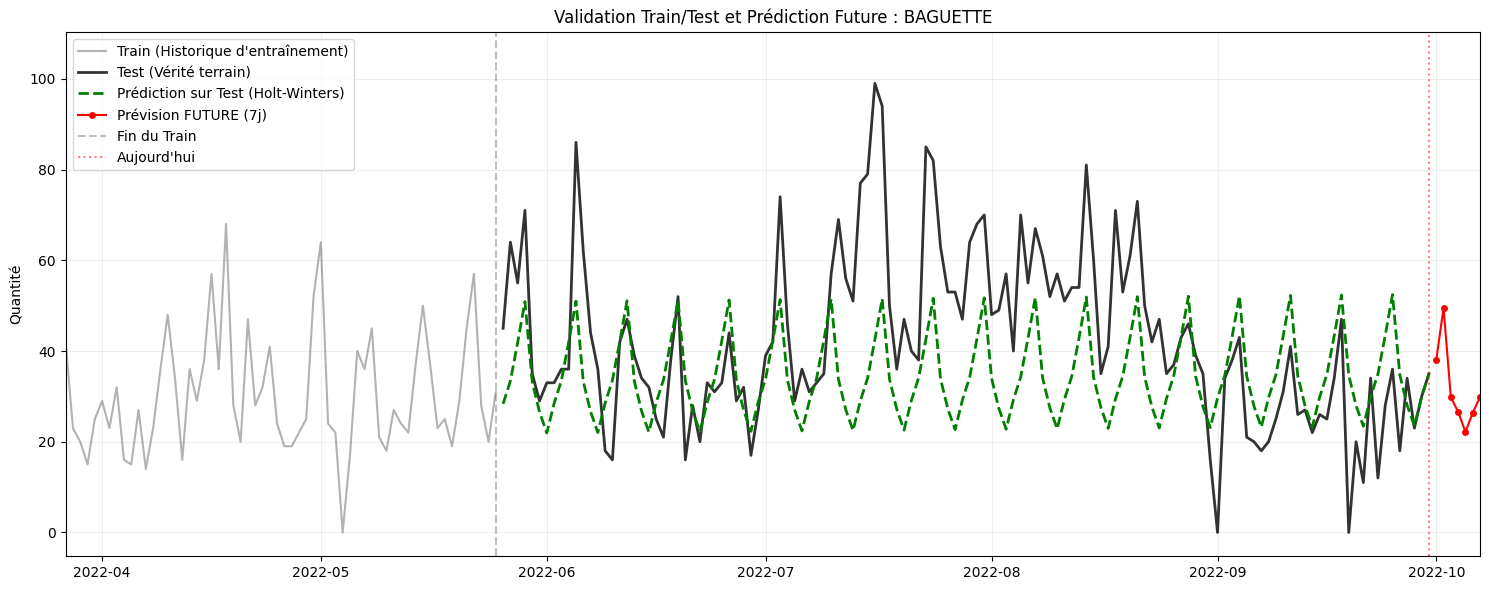

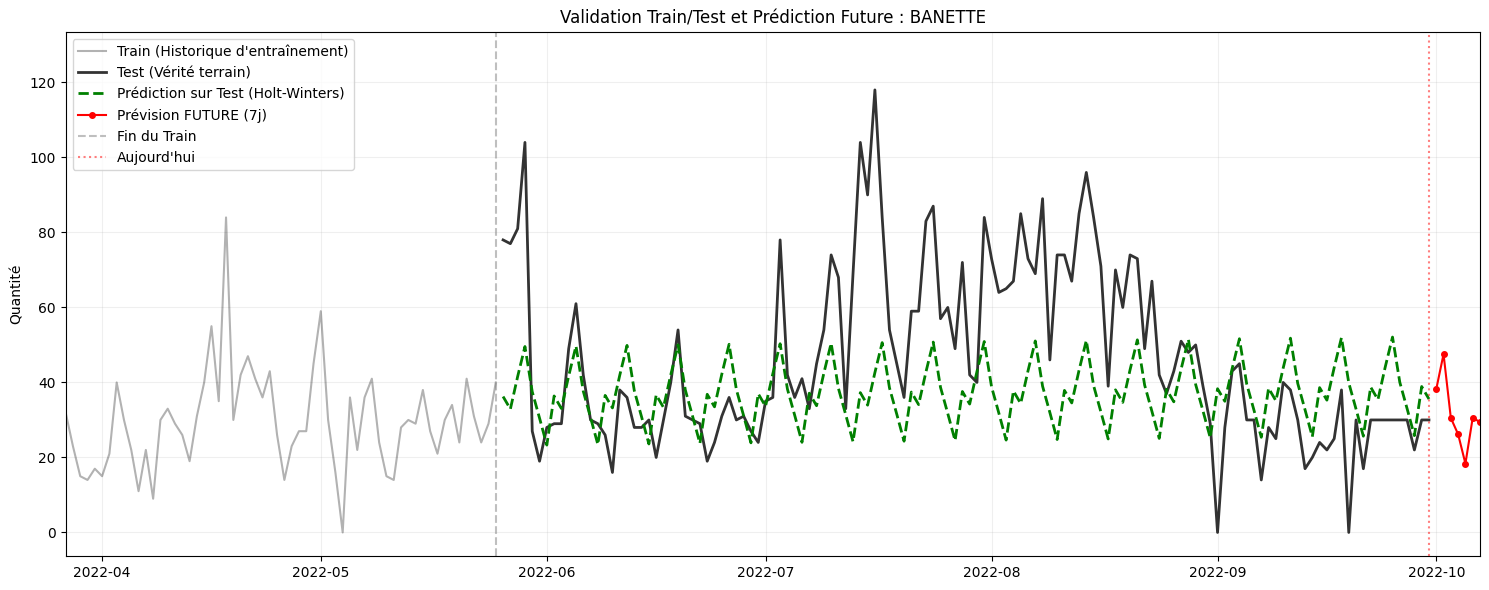

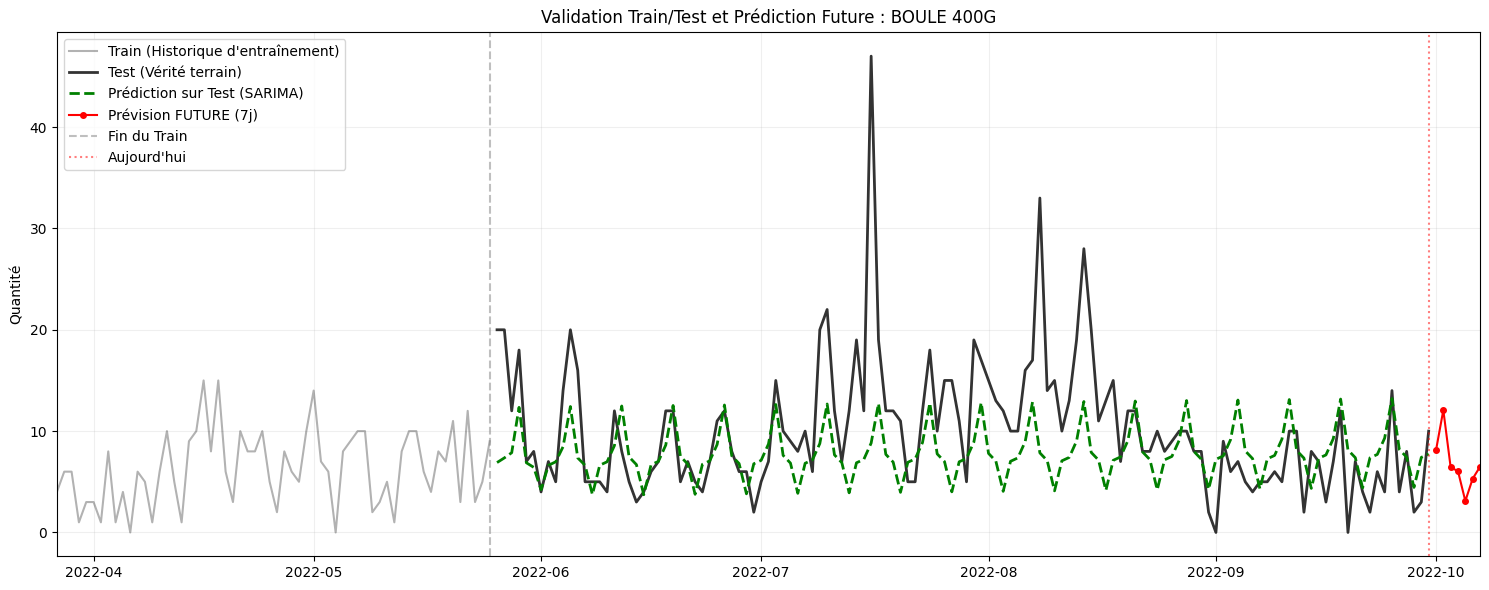

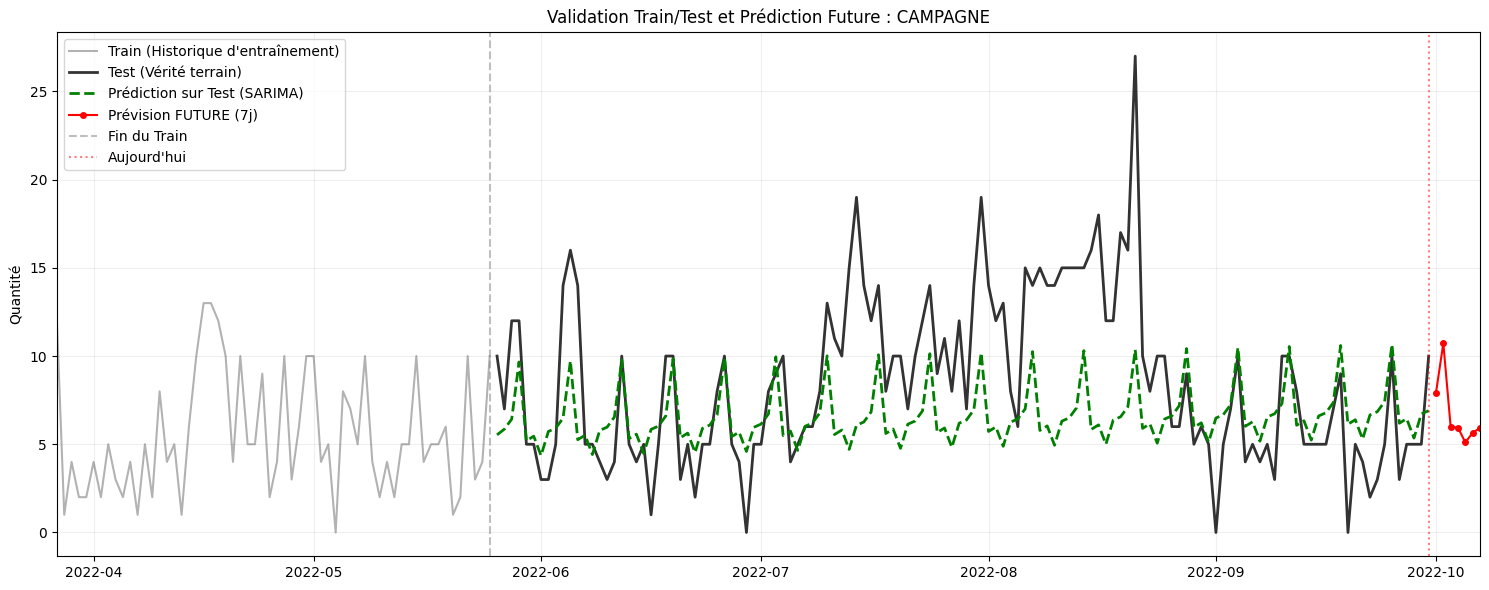

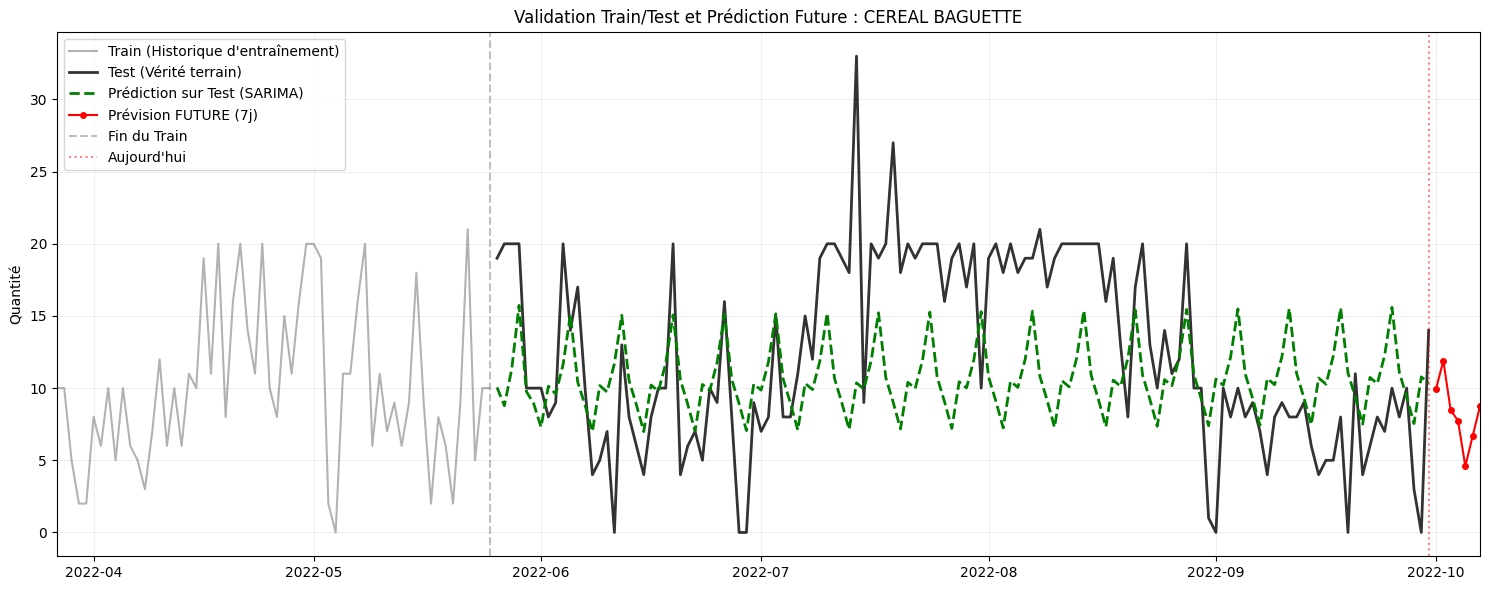

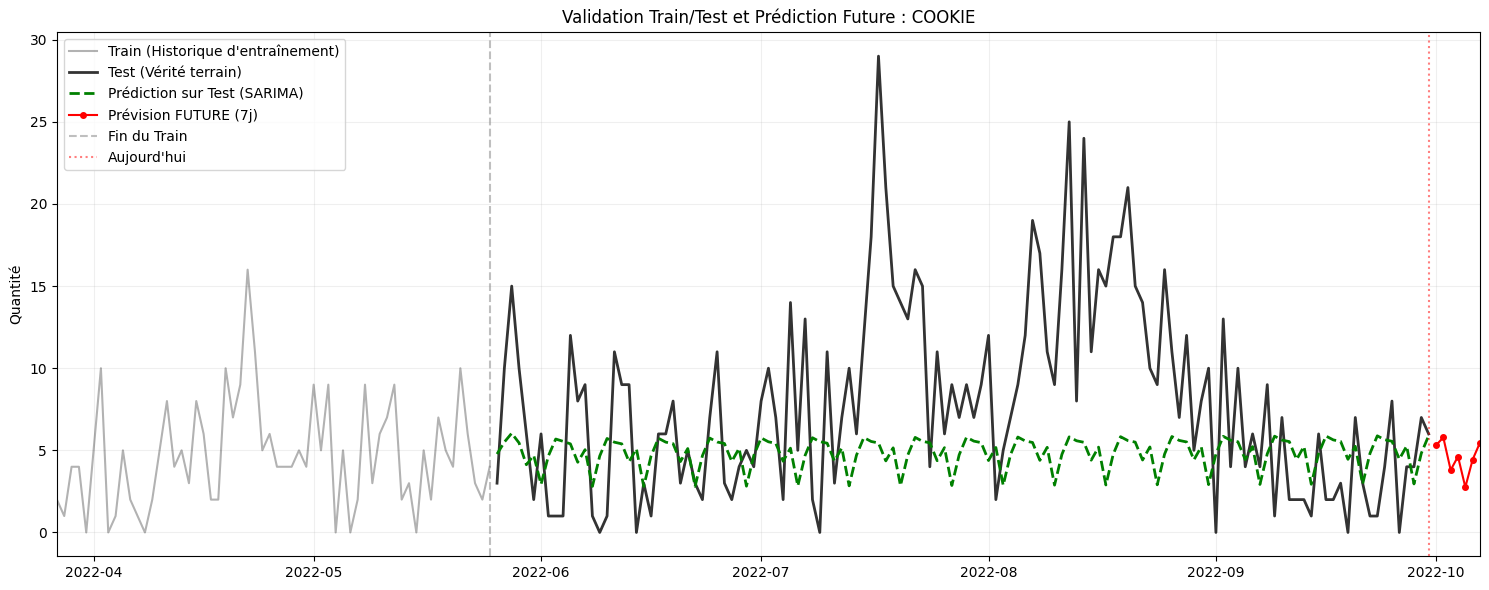

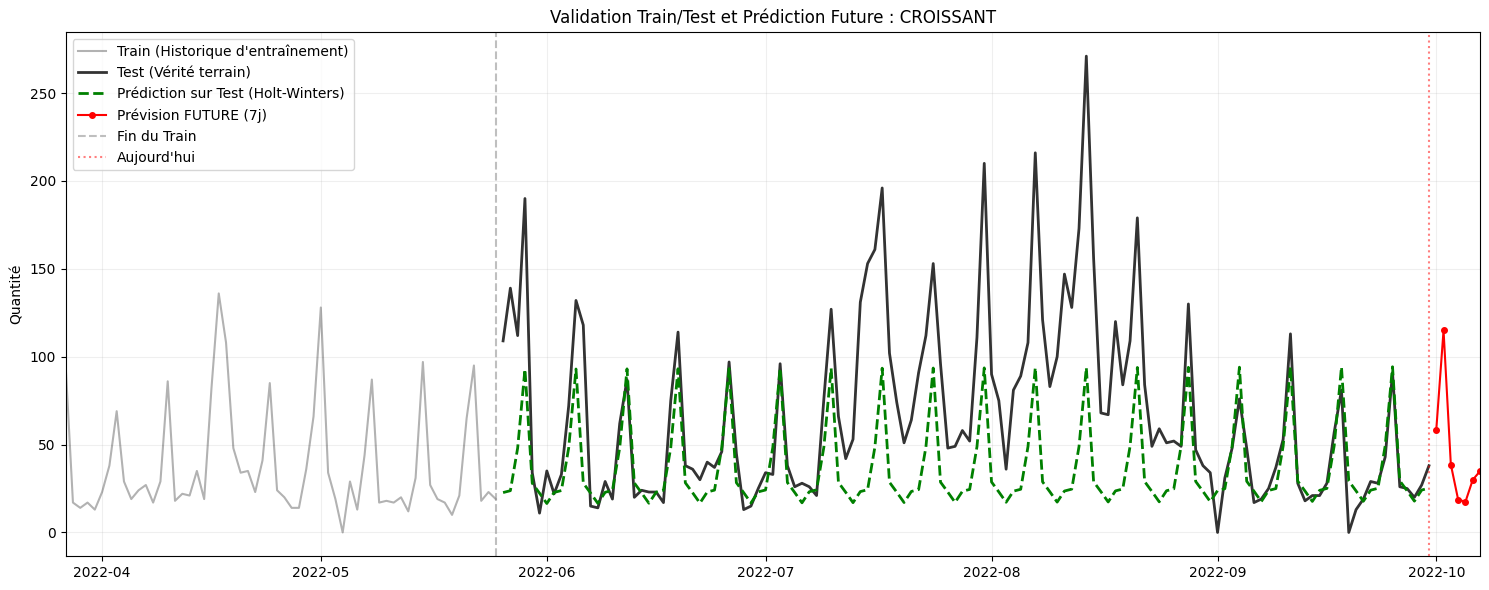

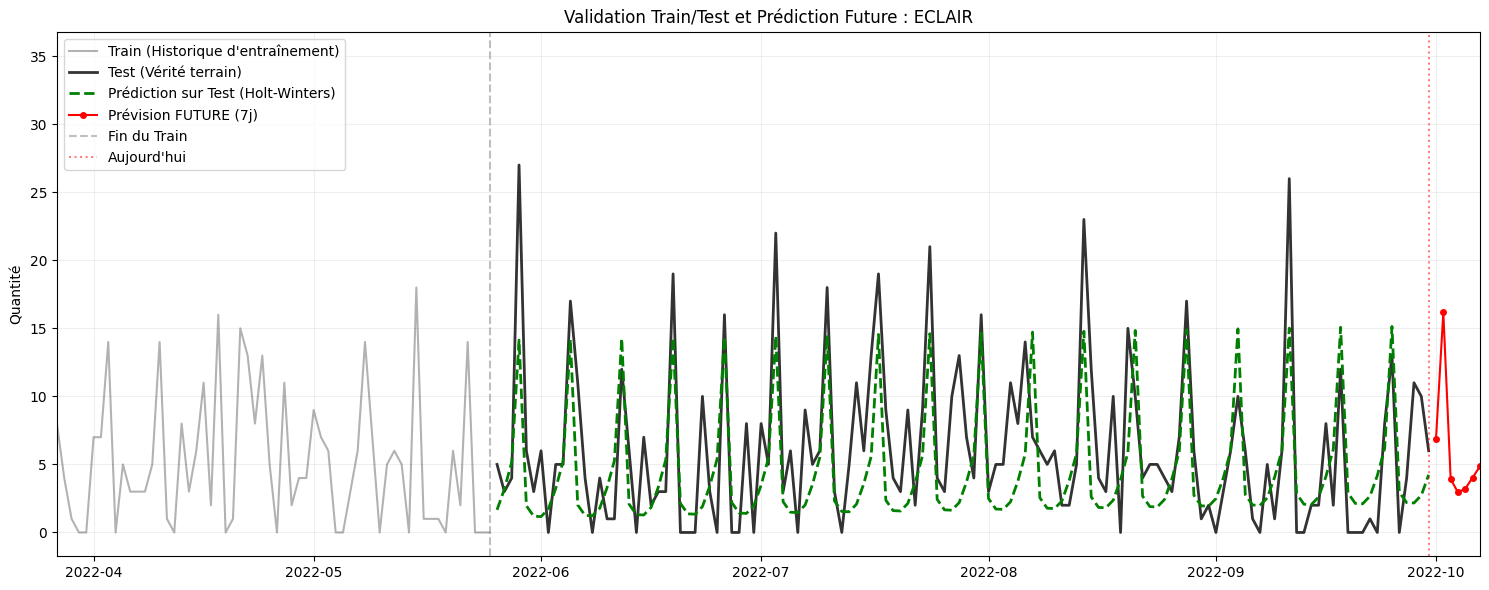

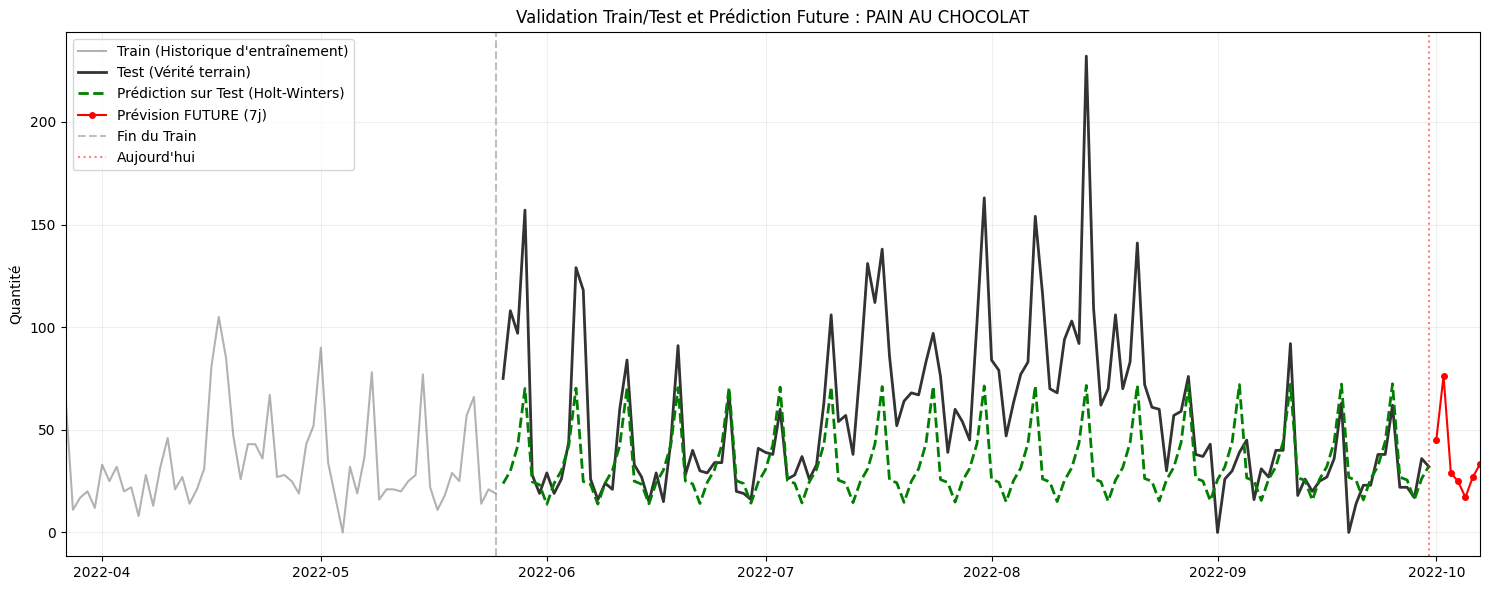

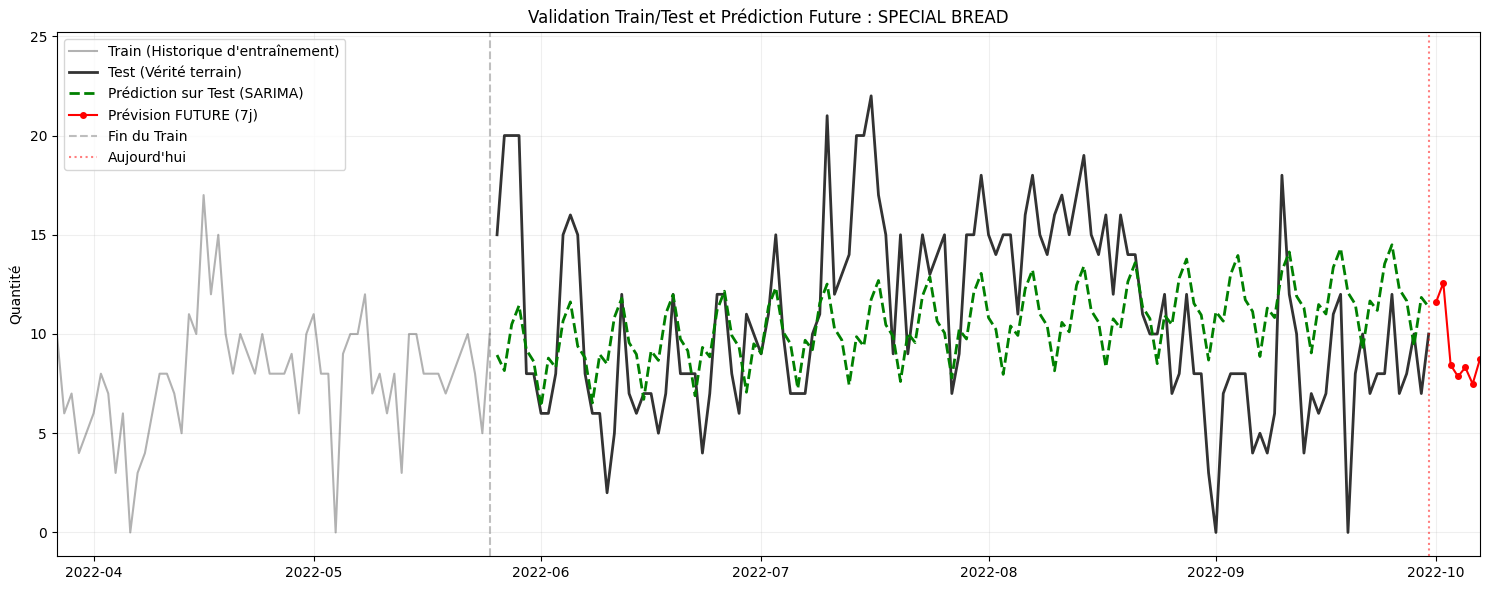

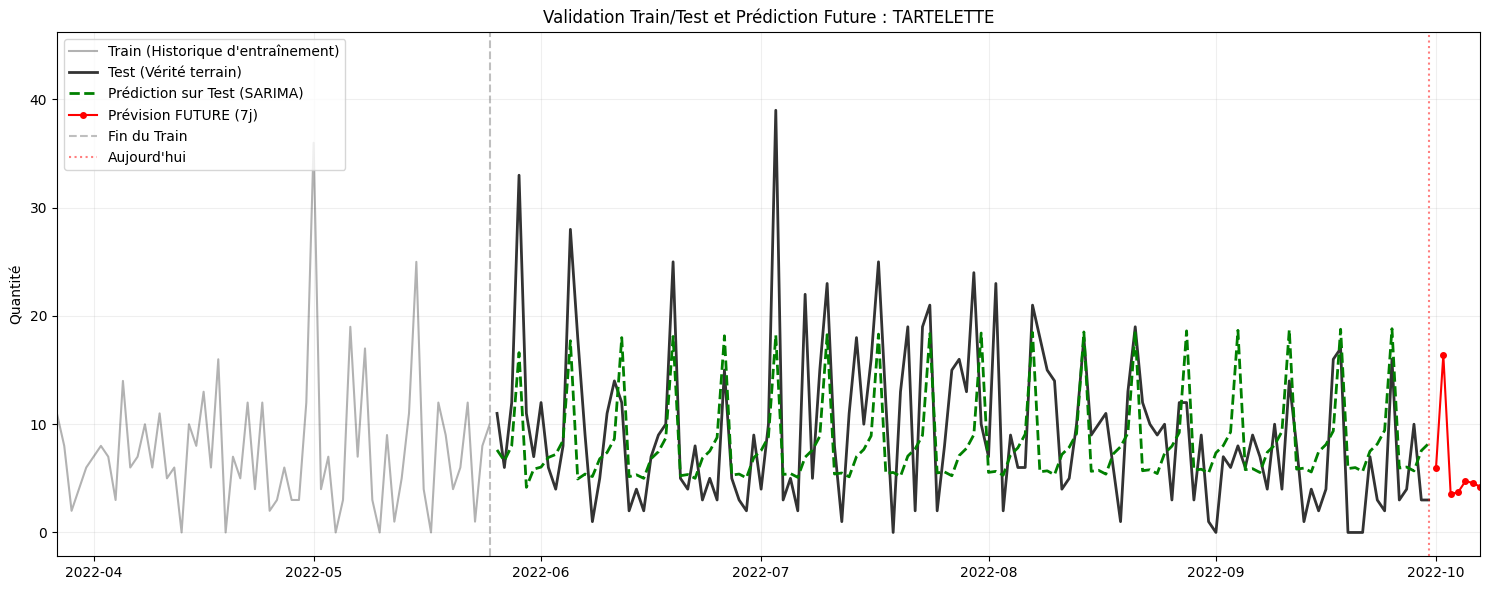

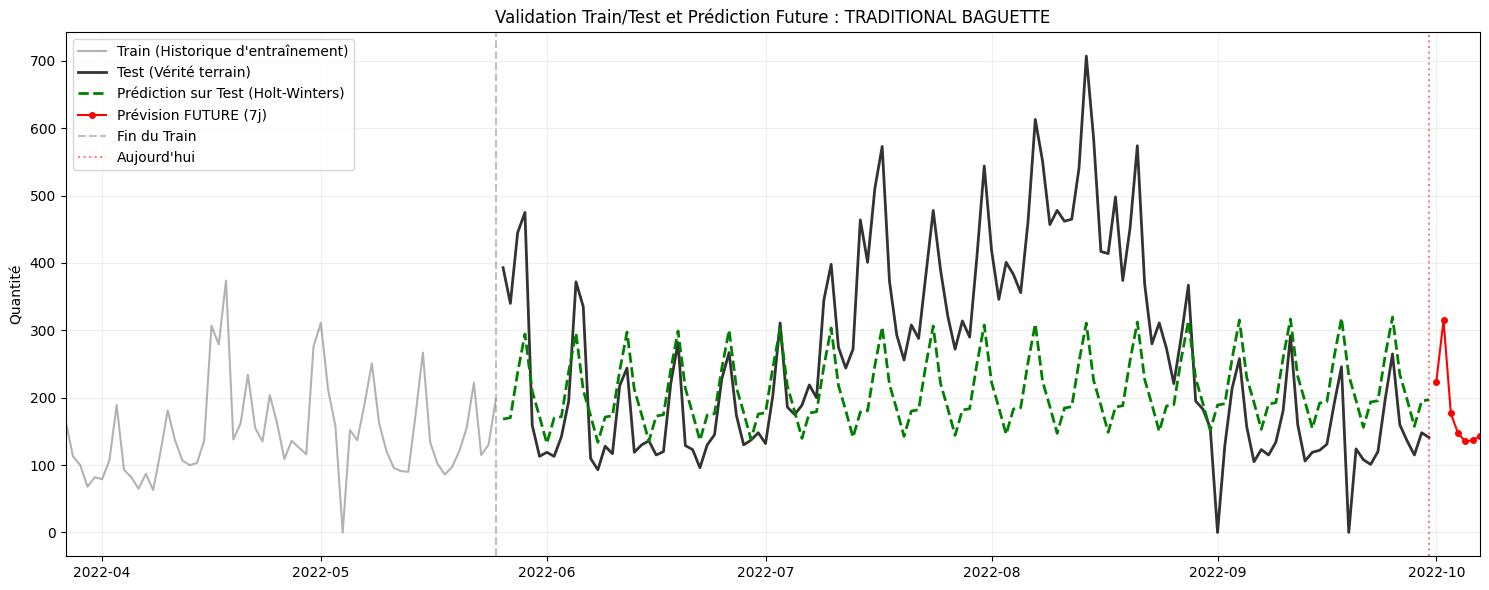

In [ ]:
import matplotlib.pyplot as plt

for produit in dict_produits.keys():
    df_prod = dict_produits[produit].asfreq('D').fillna(0)
    train_size = int(len(df_prod) * 0.8)
    train = df_prod.iloc[:train_size]
    test = df_prod.iloc[train_size:]
    
    # On récupère le modèle gagnant
    gagnant = df_comp.loc[df_comp['Produit'] == produit, 'Gagnant_MAE'].values[0]
    
    # PRÉDICTION DE TEST (On entraîne UNIQUEMENT sur train)
    if gagnant == "SARIMA":
        model_t = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7),
                          enforce_stationarity=False, enforce_invertibility=False)
        res_t = model_t.fit(disp=False)
        pred_test = res_t.forecast(steps=len(test))
    else:
        model_t = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7)
        res_t = model_t.fit()
        pred_test = res_t.forecast(len(test))
        
    # PRÉDICTION FUTURE 
    future = dict_previsions_futures[produit]

    # --- GRAPHIQUE ---
    plt.figure(figsize=(15, 6))
    
    # Tracer le TRAIN (Réalité passée)
    plt.plot(train.index, train.values, label='Train (Historique d\'entraînement)', color='black', alpha=0.3)
    
    # Tracer le TEST RÉEL (La vérité que le modèle doit deviner)
    plt.plot(test.index, test.values, label='Test (Vérité terrain)', color='black', linewidth=2, alpha=0.8)
    
    # Tracer la PRÉDICTION sur le TEST (Ce que le modèle a deviné)
    plt.plot(test.index, pred_test, label=f'Prédiction sur Test ({gagnant})', color='green', linestyle='--', linewidth=2)
    
    # Tracer la PRÉVISION FUTURE
    plt.plot(future.index, future.values, label='Prévision FUTURE (7j)', color='red', marker='o', markersize=4)
    
    # Séparations visuelles
    plt.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.5, label='Fin du Train')
    plt.axvline(x=test.index[-1], color='red', linestyle=':', alpha=0.5, label='Aujourd\'hui')

    plt.title(f"Validation Train/Test et Prédiction Future : {produit}")
    plt.ylabel("Quantité")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.2)
    
    # Zoom sur les 120 derniers jours pour voir la transition Train -> Test -> Futur
    start_zoom = test.index[0] - pd.Timedelta(days=60)
    plt.xlim(start_zoom, future.index[-1])
    
    plt.tight_layout()
    plt.show()

In [40]:
df_prev = df_predictions_finales.copy()
df_prev = df_prev[qty_ts.columns]

df_complet = pd.concat([qty_ts, df_prev])

df_complet.to_csv("data_tmp/donnees_avec_predictions.csv", index=True)